In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FOLDER = os.path.expanduser("~/Downloads")        # where the 3 CSVs are
a = pd.read_csv(os.path.join(FOLDER, "ALL_EVENTS_TABLE.csv"))

NAMES = {"pretrained": "Pretrained",
         "ckpt_q1_win60_n64": "Fine-tuned (64)",
         "ckpt_big256": "Fine-tuned (256)",
         "ckpt_q2b": "Fine-tuned (64, 2 h)"}
a["model"] = a["weights"].map(NAMES)

FLARES = ["M1.6 2023-01-22", "M2.0 2023-01-25", "X1.3 2022-03-30",
          "M5.3 2017-04-02", "X9.3 2017-09-06", "X8.2 2017-09-10"]
MODELS = ["Pretrained", "Fine-tuned (64)", "Fine-tuned (256)"]
COLORS = {"Pretrained": "#9aa5b1", "Fine-tuned (64)": "#6fa8dc", "Fine-tuned (256)": "#1f4e79"}

w60 = a[a["window"] == "-60/-36"]
up = w60[w60["orientation"] == "UPRIGHT"].pivot_table(index="flare", columns="model", values="skill").reindex(index=FLARES, columns=MODELS)
fl = w60[w60["orientation"] == "FLIPPED"].pivot_table(index="flare", columns="model", values="skill").reindex(index=FLARES, columns=MODELS)
print("loaded", len(a), "rows")

loaded 56 rows


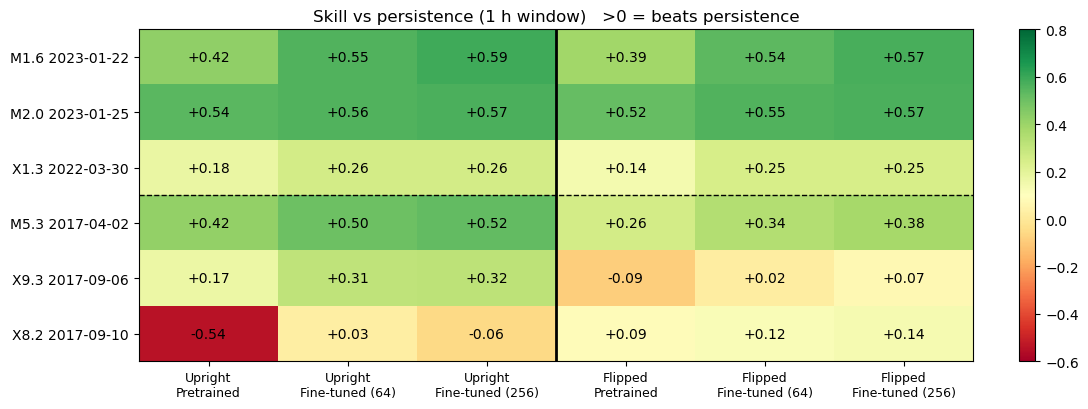

In [2]:
grid = pd.concat({"Upright": up, "Flipped": fl}, axis=1)
fig, ax = plt.subplots(figsize=(11, 4.2))
im = ax.imshow(grid.values, cmap="RdYlGn", vmin=-0.6, vmax=0.8, aspect="auto")
ax.set_xticks(range(grid.shape[1]))
ax.set_xticklabels(["{}\n{}".format(o, m) for o, m in grid.columns], fontsize=9)
ax.set_yticks(range(len(FLARES)))
ax.set_yticklabels(FLARES)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        ax.text(j, i, "{:+.2f}".format(grid.values[i, j]), ha="center", va="center", fontsize=10)
ax.axvline(2.5, color="k", lw=2)
ax.axhline(2.5, color="k", lw=1, ls="--")
ax.set_title("Skill vs persistence (1 h window)   >0 = beats persistence")
fig.colorbar(im, ax=ax, fraction=0.03)
fig.tight_layout()
fig.savefig(os.path.join(FOLDER, "table_skill.png"), dpi=200)
plt.show()

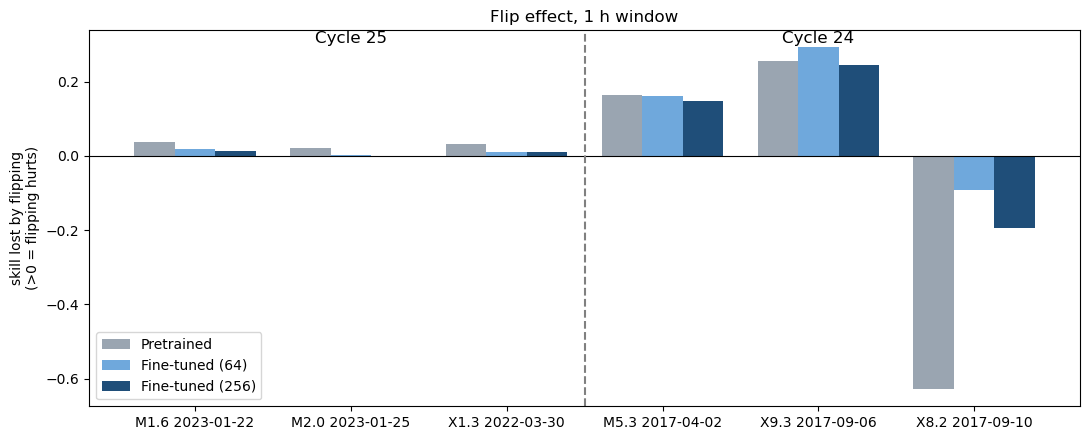

In [3]:
drop = (up - fl)          # skill lost by flipping; >0 = flipping hurts
x = np.arange(len(FLARES)); wd = 0.26
fig, ax = plt.subplots(figsize=(11, 4.5))
for k, m in enumerate(MODELS):
    ax.bar(x + (k - 1) * wd, drop[m].values, wd, label=m, color=COLORS[m])
ax.axhline(0, color="k", lw=0.8)
ax.axvline(2.5, color="gray", ls="--")
ax.text(1, ax.get_ylim()[1] * 0.9, "Cycle 25", ha="center", fontsize=12)
ax.text(4, ax.get_ylim()[1] * 0.9, "Cycle 24", ha="center", fontsize=12)
ax.set_xticks(x); ax.set_xticklabels(FLARES)
ax.set_ylabel("skill lost by flipping\n(>0 = flipping hurts)")
ax.set_title("Flip effect, 1 h window")
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(os.path.join(FOLDER, "plot_flip_effect.png"), dpi=200)
plt.show()

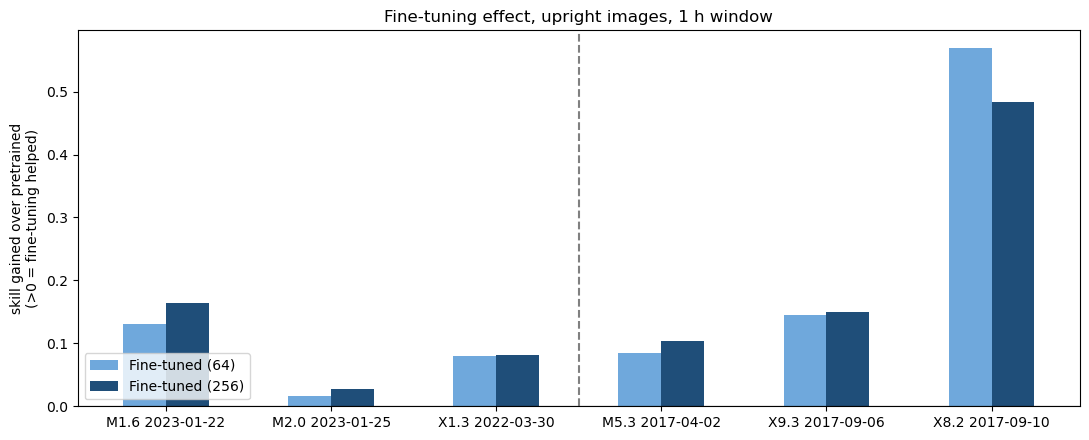

saved 3 PNGs to C:\Users\Joao Pereira/Downloads


In [4]:
gain = up.sub(up["Pretrained"], axis=0)[["Fine-tuned (64)", "Fine-tuned (256)"]]
fig, ax = plt.subplots(figsize=(11, 4.5))
for k, m in enumerate(gain.columns):
    ax.bar(x + (k - 0.5) * wd, gain[m].values, wd, label=m, color=COLORS[m])
ax.axhline(0, color="k", lw=0.8)
ax.axvline(2.5, color="gray", ls="--")
ax.set_xticks(x); ax.set_xticklabels(FLARES)
ax.set_ylabel("skill gained over pretrained\n(>0 = fine-tuning helped)")
ax.set_title("Fine-tuning effect, upright images, 1 h window")
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(os.path.join(FOLDER, "plot_finetune_effect.png"), dpi=200)
plt.show()
print("saved 3 PNGs to", FOLDER)

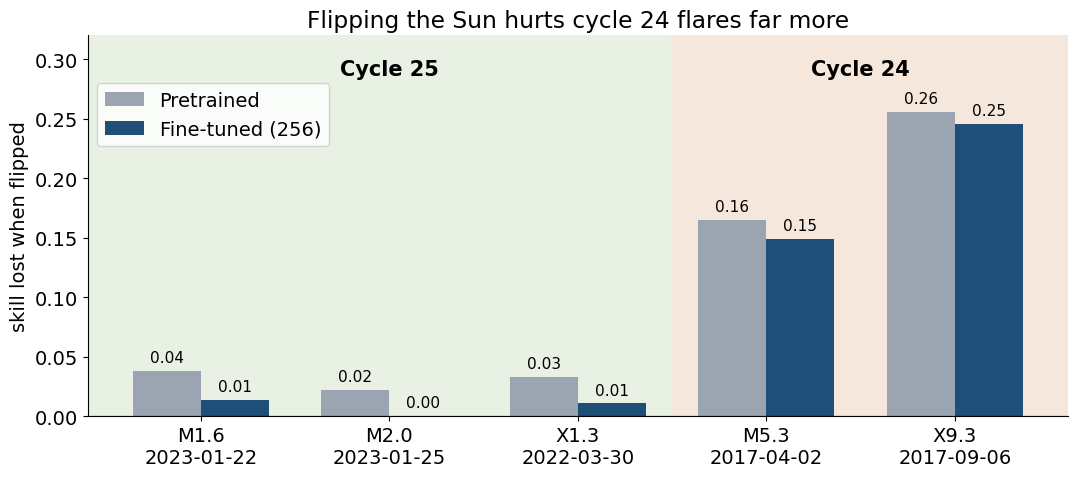

In [5]:
SHOW = ["M1.6 2023-01-22", "M2.0 2023-01-25", "X1.3 2022-03-30",
        "M5.3 2017-04-02", "X9.3 2017-09-06"]
d = (up - fl).loc[SHOW, ["Pretrained", "Fine-tuned (256)"]]
x = np.arange(len(SHOW)); wd = 0.36
plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(figsize=(11, 5))
ax.axvspan(-0.6, 2.5, color="#e8f1e4", zorder=0)
ax.axvspan(2.5, 4.6, color="#f6e7dc", zorder=0)
for k, m in enumerate(d.columns):
    b = ax.bar(x + (k - 0.5) * wd, d[m].values, wd, label=m, color=COLORS[m], zorder=2)
    for r, v in zip(b, d[m].values):
        ax.text(r.get_x() + r.get_width() / 2, max(v, 0) + 0.005,
                "{:.2f}".format(0.0 if abs(v) < 0.005 else v),
                ha="center", va="bottom", fontsize=11)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlim(-0.6, 4.6)
ax.set_ylim(0, 0.32)
ax.text(1, 0.30, "Cycle 25", ha="center", va="top", fontsize=15, weight="bold")
ax.text(3.5, 0.30, "Cycle 24", ha="center", va="top", fontsize=15, weight="bold")
ax.set_xticks(x)
ax.set_xticklabels([s.replace(" ", "\n") for s in SHOW])
ax.set_ylabel("skill lost when flipped")
ax.set_title("Flipping the Sun hurts cycle 24 flares far more")
ax.legend(loc="upper left", bbox_to_anchor=(0, 0.9))
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(FOLDER, "slide_flip_by_cycle.png"), dpi=200)
plt.show()


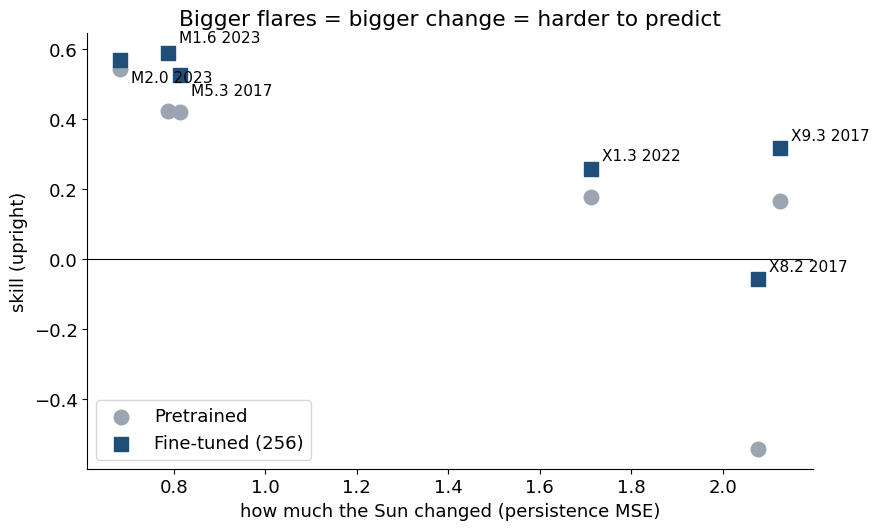

In [6]:
plt.rcParams.update({"font.size": 13})
pers = w60[(w60["orientation"] == "UPRIGHT") & (w60["model"] == "Pretrained")].set_index("flare")["mse_persistence"].reindex(FLARES)
OFF1 = {"M2.0 2023-01-25": (8, -16), "M1.6 2023-01-22": (8, 8), "M5.3 2017-04-02": (8, -14)}
fig, ax = plt.subplots(figsize=(9, 5.5))
for m, mk in (("Pretrained", "o"), ("Fine-tuned (256)", "s")):
    ax.scatter(pers.values, up[m].values, s=110, marker=mk, color=COLORS[m], label=m, zorder=3)
for f in FLARES:
    ax.annotate(f.split()[0] + " " + f.split()[1][:4], (pers[f], up.loc[f, "Fine-tuned (256)"]),
                textcoords="offset points", xytext=OFF1.get(f, (8, 6)), fontsize=11)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("how much the Sun changed (persistence MSE)")
ax.set_ylabel("skill (upright)")
ax.set_title("Bigger flares = bigger change = harder to predict")
ax.legend(loc="lower left")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(FOLDER, "plot_size_vs_skill.png"), dpi=200)
plt.show()

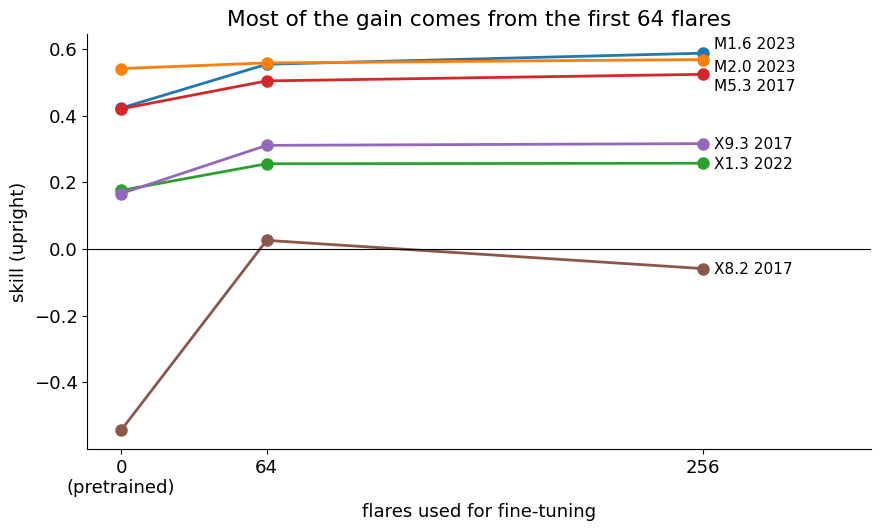

In [7]:
n_train = [0, 64, 256]
OFF2 = {"M1.6 2023-01-22": (8, 3), "M2.0 2023-01-25": (8, -9), "M5.3 2017-04-02": (8, -12)}
fig, ax = plt.subplots(figsize=(9, 5.5))
for f in FLARES:
    y = up.loc[f, MODELS].values
    ax.plot(n_train, y, "-o", lw=2, ms=8)
    ax.annotate(f.split()[0] + " " + f.split()[1][:4], (256, y[-1]),
                textcoords="offset points", xytext=OFF2.get(f, (8, -4)), fontsize=11)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(n_train)
ax.set_xticklabels(["0\n(pretrained)", "64", "256"])
ax.set_xlim(-15, 330)
ax.set_xlabel("flares used for fine-tuning")
ax.set_ylabel("skill (upright)")
ax.set_title("Most of the gain comes from the first 64 flares")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(FOLDER, "plot_training_size.png"), dpi=200)
plt.show()

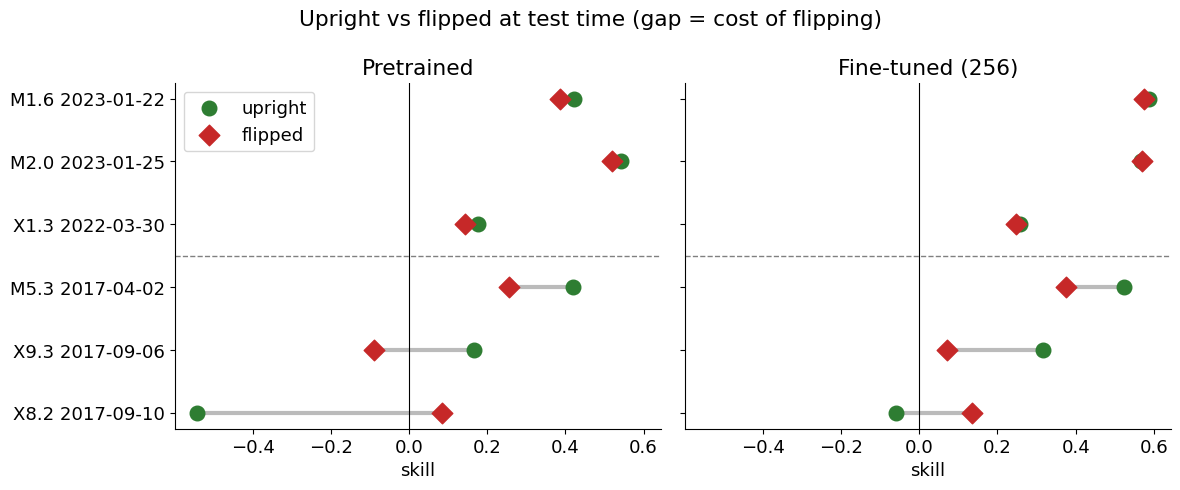

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, sharex=True)
y = np.arange(len(FLARES))[::-1]
for ax, m in zip(axes, ["Pretrained", "Fine-tuned (256)"]):
    for yi, f in zip(y, FLARES):
        ax.plot([fl.loc[f, m], up.loc[f, m]], [yi, yi], color="#bbbbbb", lw=3, zorder=1)
    ax.scatter(up[m].values, y, s=110, color="#2e7d32", label="upright", zorder=2)
    ax.scatter(fl[m].values, y, s=110, color="#c62828", marker="D", label="flipped", zorder=2)
    ax.axvline(0, color="k", lw=0.8)
    ax.axhline(2.5, color="gray", ls="--", lw=1)
    ax.set_title(m)
    ax.set_xlabel("skill")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_yticks(y)
axes[0].set_yticklabels(FLARES)
axes[0].legend(loc="upper left")
fig.suptitle("Upright vs flipped at test time (gap = cost of flipping)")
fig.tight_layout()
fig.savefig(os.path.join(FOLDER, "plot_upright_vs_flipped.png"), dpi=200)
plt.show()

In [9]:
plt.rcParams.update({"font.size": 14, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.titlesize": 16})
CYC = {"M1.6 2023-01-22": 25, "M2.0 2023-01-25": 25, "X1.3 2022-03-30": 25,
       "M5.3 2017-04-02": 24, "X9.3 2017-09-06": 24, "X8.2 2017-09-10": 24}
CCOL = {25: "#1b7f79", 24: "#d9731a"}
SHORT = {f: f.split()[0] + " (" + f.split()[1][:4] + ")" for f in FLARES}
pers = w60[(w60["orientation"] == "UPRIGHT") & (w60["model"] == "Pretrained")].set_index("flare")["mse_persistence"].reindex(FLARES)
from matplotlib.lines import Line2D
cyc_legend = [Line2D([0], [0], color=CCOL[25], lw=4, label="Cycle 25 (2022-23)"),
              Line2D([0], [0], color=CCOL[24], lw=4, label="Cycle 24 (2017)")]

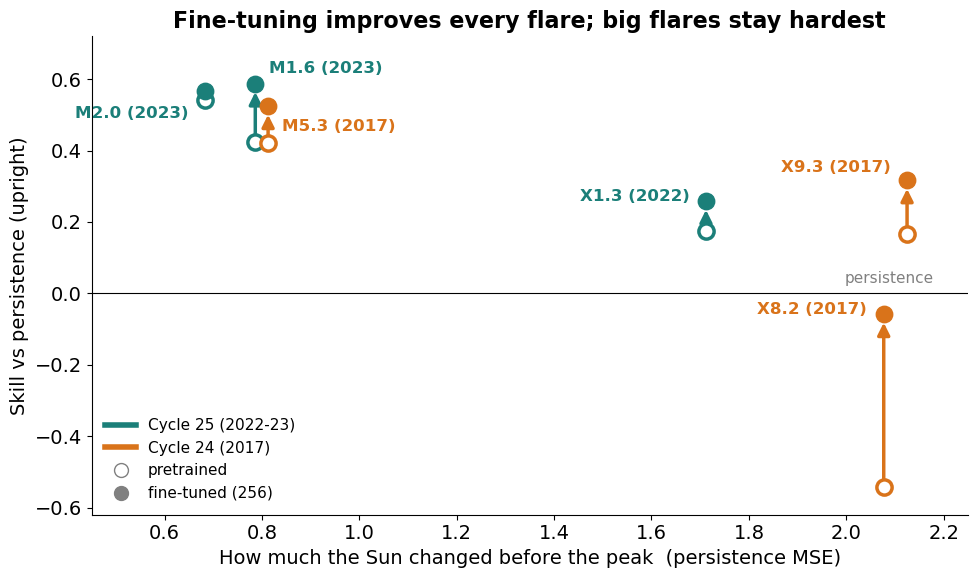

In [10]:
LAB = {"M2.0 2023-01-25": (-12, -20, "right"), "M1.6 2023-01-22": (10, 8, "left"),
       "M5.3 2017-04-02": (10, -18, "left"), "X1.3 2022-03-30": (-12, 0, "right"),
       "X9.3 2017-09-06": (-12, 6, "right"), "X8.2 2017-09-10": (-12, 0, "right")}
fig, ax = plt.subplots(figsize=(10, 6))
for f in FLARES:
    c = CCOL[CYC[f]]; x0 = pers[f]
    y0, y1 = up.loc[f, "Pretrained"], up.loc[f, "Fine-tuned (256)"]
    ax.annotate("", xy=(x0, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=c, lw=2.5, mutation_scale=18, shrinkA=6, shrinkB=6))
    ax.scatter(x0, y0, s=120, facecolors="white", edgecolors=c, linewidths=2.5, zorder=3)
    ax.scatter(x0, y1, s=140, color=c, zorder=3)
    dx, dy, ha = LAB[f]
    ax.annotate(SHORT[f], (x0, y1), textcoords="offset points", xytext=(dx, dy), ha=ha, fontsize=12, color=c, weight="bold")
ax.axhline(0, color="k", lw=0.8)
ax.text(2.18, 0.02, "persistence", fontsize=11, color="gray", ha="right", va="bottom")
ax.set_xlabel("How much the Sun changed before the peak  (persistence MSE)")
ax.set_ylabel("Skill vs persistence (upright)")
ax.set_title("Fine-tuning improves every flare; big flares stay hardest")
ax.set_xlim(0.45, 2.25)
ax.set_ylim(-0.62, 0.72)
h = cyc_legend + [Line2D([0], [0], marker="o", color="gray", mfc="white", lw=0, ms=10, label="pretrained"),
                  Line2D([0], [0], marker="o", color="gray", lw=0, ms=10, label="fine-tuned (256)")]
ax.legend(handles=h, loc="lower left", fontsize=11, frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(FOLDER, "v2_finetune_arrows.png"), dpi=200)
plt.show()

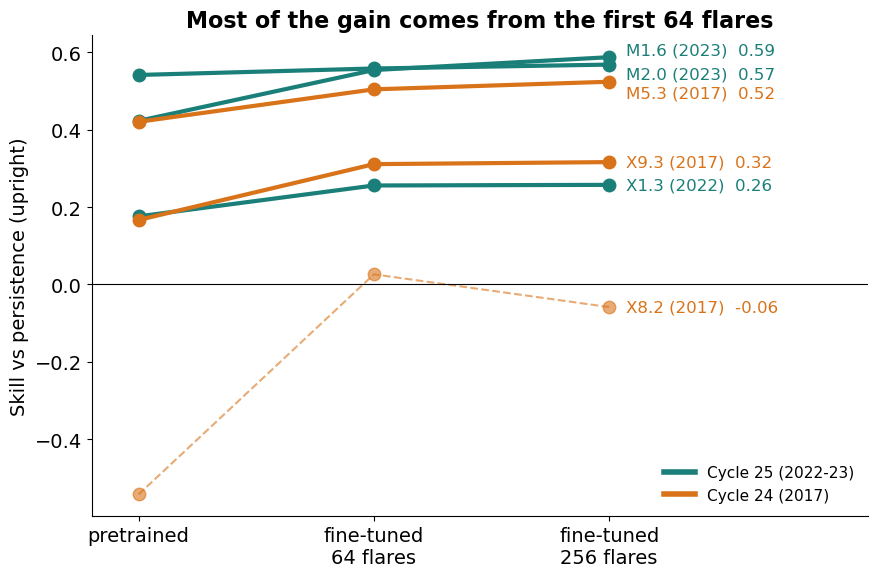

In [11]:
xs = [0, 1, 2]
fig, ax = plt.subplots(figsize=(9, 6))
for f in FLARES:
    yv = up.loc[f, MODELS].values
    out = f.startswith("X8.2")
    ax.plot(xs, yv, marker="o", color=CCOL[CYC[f]], lw=1.5 if out else 3, ms=9, ls="--" if out else "-", alpha=0.6 if out else 1)
    ax.annotate("{}  {:.2f}".format(SHORT[f], yv[-1]), (2, yv[-1]), textcoords="offset points",
                xytext=(12, {"M2.0 2023-01-25": -7, "M1.6 2023-01-22": 5, "M5.3 2017-04-02": -8}.get(f, 0)),
                va="center", fontsize=12, color=CCOL[CYC[f]])
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(xs)
ax.set_xticklabels(["pretrained", "fine-tuned\n64 flares", "fine-tuned\n256 flares"])
ax.set_xlim(-0.2, 3.1)
ax.set_ylabel("Skill vs persistence (upright)")
ax.set_title("Most of the gain comes from the first 64 flares")
ax.legend(handles=cyc_legend, loc="lower right", fontsize=11, frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(FOLDER, "v2_training_size.png"), dpi=200)
plt.show()

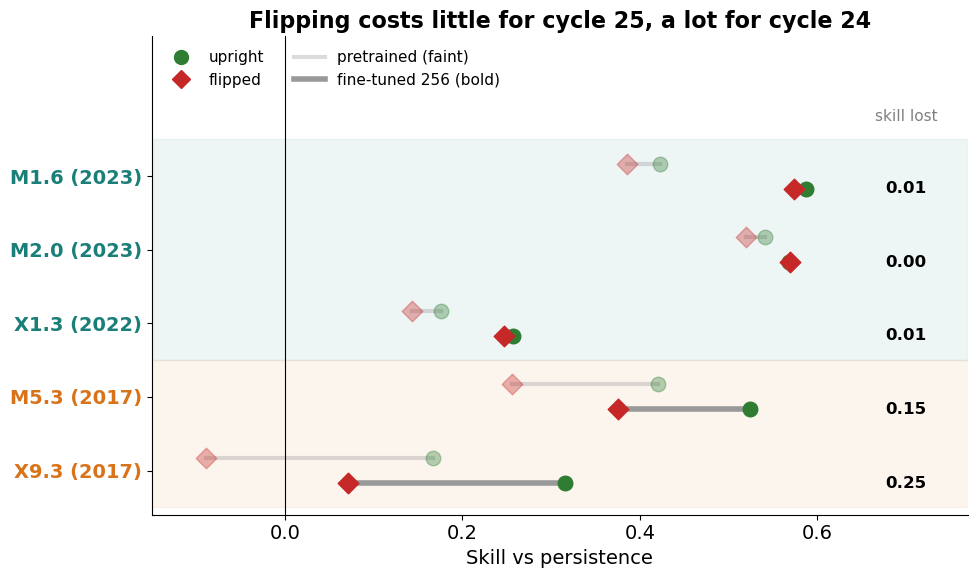

In [12]:
SHOW = FLARES[:5]
fig, ax = plt.subplots(figsize=(10, 6))
yb = np.arange(len(SHOW))[::-1].astype(float)
ax.axhspan(1.5, 4.5, color=CCOL[25], alpha=0.07)
ax.axhspan(-0.5, 1.5, color=CCOL[24], alpha=0.07)
for yi, f in zip(yb, SHOW):
    for m, off, alpha, lw in (("Pretrained", 0.17, 0.35, 3), ("Fine-tuned (256)", -0.17, 1.0, 4)):
        u, v = up.loc[f, m], fl.loc[f, m]
        ax.plot([v, u], [yi + off, yi + off], color="#999999", lw=lw, alpha=alpha, zorder=1)
        ax.scatter(u, yi + off, s=110, color="#2e7d32", alpha=alpha, zorder=2)
        ax.scatter(v, yi + off, s=110, color="#c62828", marker="D", alpha=alpha, zorder=2)
    g = up.loc[f, "Fine-tuned (256)"] - fl.loc[f, "Fine-tuned (256)"]
    ax.text(0.70, yi - 0.17, "{:.2f}".format(max(g, 0.0)), va="center", ha="center", fontsize=12, weight="bold")
ax.text(0.70, 4.75, "skill lost", fontsize=11, color="gray", ha="center")
ax.set_yticks(yb)
ax.set_yticklabels([SHORT[f] for f in SHOW])
for t, f in zip(ax.get_yticklabels(), SHOW):
    t.set_color(CCOL[CYC[f]]); t.set_fontweight("bold")
ax.set_xlim(-0.15, 0.77)
ax.set_ylim(-0.6, 5.9)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Skill vs persistence")
ax.set_title("Flipping costs little for cycle 25, a lot for cycle 24")
h = [Line2D([0], [0], marker="o", color="#2e7d32", lw=0, ms=10, label="upright"),
     Line2D([0], [0], marker="D", color="#c62828", lw=0, ms=9, label="flipped"),
     Line2D([0], [0], color="#999999", lw=3, alpha=0.35, label="pretrained (faint)"),
     Line2D([0], [0], color="#999999", lw=4, label="fine-tuned 256 (bold)")]
ax.legend(handles=h, loc="upper left", ncol=2, fontsize=11, frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(FOLDER, "v2_flip_cost.png"), dpi=200)
plt.show()

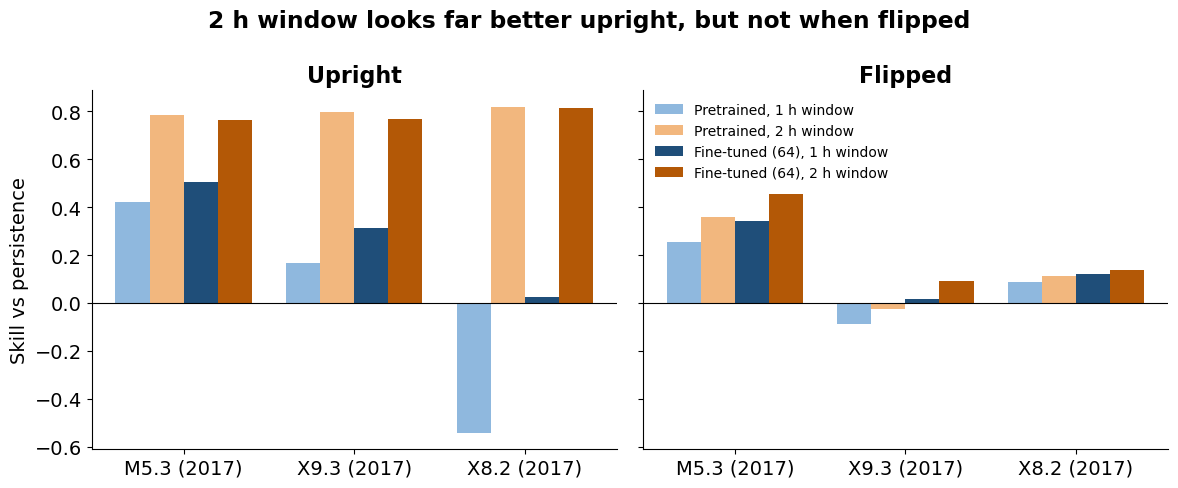

In [13]:
EV = ["M5.3 2017-04-02", "X9.3 2017-09-06", "X8.2 2017-09-10"]
PAIRS = [("Pretrained", "pretrained", "pretrained"), ("Fine-tuned (64)", "ckpt_q1_win60_n64", "ckpt_q2b")]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
xw = np.arange(len(EV)); wd = 0.2
for ax, orient in zip(axes, ["UPRIGHT", "FLIPPED"]):
    k = 0
    for label, w1, w2 in PAIRS:
        for win, wname, col in (("-60/-36", w1, "#8fb8de" if label == "Pretrained" else "#1f4e79"),
                                ("-120/-60", w2, "#f2b77e" if label == "Pretrained" else "#b35806")):
            s = a[(a["window"] == win) & (a["weights"] == wname) & (a["orientation"] == orient)].set_index("flare")["skill"].reindex(EV)
            ax.bar(xw + (k - 1.5) * wd, s.values, wd, color=col,
                   label="{}, {} window".format(label, "1 h" if win == "-60/-36" else "2 h"))
            k += 1
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(xw); ax.set_xticklabels([SHORT[f] for f in EV])
    ax.set_title(orient.capitalize())
axes[0].set_ylabel("Skill vs persistence")
axes[1].legend(loc="upper left", fontsize=10, frameon=False)
fig.suptitle("2 h window looks far better upright, but not when flipped", fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FOLDER, "v2_window_compare.png"), dpi=200)
plt.show()